# Calibration: Residential and Companies

This notebook calibrates impact functions for the two remaining uncalibrated asset types in the Brazil starter pack, following the method of `06a_calibration_schools.ipynb`:

- **Residential** (loss function 101, affected function 102) — calibrated against the Porto Alegre 'Affected' count and the IDB economic-loss figure for residential buildings
- **Companies** (loss function 201, affected function 202) — calibrated against the 'Business: All' observations

The approach per asset type is identical to 06a:
1. a step-function grid search for the *affected* count, and
2. a 2-D grid search (max intensity × max damage) scaling the first-guess loss curve, followed by an expert-judgement filter, for *economic loss*.

Differences from 06a: both asset types run through one parametrized loop; the loss grid uses the same bounds but a slightly coarser step (Residential has 20,187 exposure points, so each risk calculation is ~165× the schools workload); and the calibrated Entity files are written automatically at the end instead of copied by hand.

In [1]:
from pathlib import Path

ENTITY_DIR = "../data/entity_files_uncalibrated/"
CALIBRATED_ENTITY_DIR = "../data/entity_files_calibrated/"

HAZARD_DIR = "../data/hazard/"
HAZARD_FILE = "Brazil_Porto_Alegre_2024_duration.tif"
haz_filepath = Path(HAZARD_DIR) / HAZARD_FILE

OBSERVATIONS_DIR = "../data/observations/"
OBSERVATIONS_FILE = "observations_2024.csv"
observations_filepath = Path(OBSERVATIONS_DIR) / OBSERVATIONS_FILE

# Per-asset-type configuration
ASSET_CONFIGS = {
    "Residential": {
        "entity_file": "Porto_Alegre_BRAZIL_Entity_Floods_Residential.xlsx",
        "calibrated_file": "Porto_Alegre_BRAZIL_Entity_Floods_Residential_calibrated.xlsx",
        "impf_id_loss": 101,
        "impf_id_affected": 102,
        "obs_asset_type": "Residential",
        "count_unit": "number of residential buildings",
    },
    "Companies": {
        "entity_file": "Porto_Alegre_BRAZIL_Entity_Floods_Companies.xlsx",
        "calibrated_file": "Porto_Alegre_BRAZIL_Entity_Floods_Companies_calibrated.xlsx",
        "impf_id_loss": 201,
        "impf_id_affected": 202,
        "obs_asset_type": "Business: All",
        "count_unit": "number of businesses",
    },
}

## Load the components of risk

In [2]:
import copy
from climada.entity import Entity

impf_column = "impf_FL"

# Same helper as 06a: re-read the Entity with the 'count' column as value when
# calibrating against numbers of affected buildings
def read_entity(path, value_column):
    entity = Entity.from_excel(path)
    if value_column == "value":
        return entity
    new_gdf = entity.exposures.gdf.copy()
    new_gdf["value"] = new_gdf[value_column]
    entity.exposures.set_gdf(new_gdf)
    return entity

entities = {}
for asset, cfg in ASSET_CONFIGS.items():
    path = Path(ENTITY_DIR) / cfg["entity_file"]

    entity_usd = read_entity(path, value_column="value")
    entity_usd.exposures.ref_year = 2025
    entity_usd.exposures.value_unit = "USD"
    entity_usd.exposures.description = f"{asset}: economic value"

    entity_count = read_entity(path, value_column="count")
    entity_count.exposures.ref_year = 2025
    entity_count.exposures.value_unit = cfg["count_unit"]
    entity_count.exposures.description = f"{asset}: count"

    entities[asset] = {"usd": entity_usd, "count": entity_count}
    print(
        f"{asset}: {len(entity_usd.exposures.gdf)} points, "
        f"total value {entity_usd.exposures.gdf['value'].sum():,.0f} USD, "
        f"total count {entity_count.exposures.gdf['value'].sum():,.0f}"
    )

Residential: 20187 points, total value 69,311,916,748 USD, total count 762,239


Companies: 4366 points, total value 3,655,929,050 USD, total count 9,742


### Load Hazard data (2024 flood duration reconstruction)

In [3]:
import numpy as np
from climada.hazard import Hazard

haz = Hazard.from_raster(
    files_intensity=haz_filepath,
    attrs={
        "unit": "days",
        "event_name": ["2024 Flood"],
        "frequency": np.array([1]),
    },
    haz_type="FL",
)

for asset in ASSET_CONFIGS:
    for kind in ("usd", "count"):
        exp = entities[asset][kind].exposures
        exp.assign_centroids(hazard=haz, overwrite=True)
        assert exp.gdf["centr_FL"].isna().sum() == 0, (
            f"{asset}/{kind}: some exposures have no assigned hazard centroid"
        )
print("Centroids assigned for all entities")

Centroids assigned for all entities


### Load observations

As in 06a we use the Porto Alegre dashboard for 'Affected' counts and the IDB post-disaster assessment for economic losses, converting BRL to USD at the 2024 exchange rate.

In [4]:
import pandas as pd

BRL_to_USD = 0.18  # 2024 exchange rate, as in 06a

obs = pd.read_csv(observations_filepath)
targets = {}
for asset, cfg in ASSET_CONFIGS.items():
    obs_asset = obs[obs["Asset type"] == cfg["obs_asset_type"]]

    obs_affected = obs_asset[
        (obs_asset["Impact type"] == "Affected") & (obs_asset["Source"] == "Porto Alegre")
    ]["Value"]
    assert len(obs_affected) == 1, f"{asset}: expected one 'Affected' observation"

    obs_loss = obs_asset[
        (obs_asset["Impact type"] == "Economic loss") & (obs_asset["Source"] == "IDB")
    ]["Value"]
    assert len(obs_loss) == 1, f"{asset}: expected one 'Economic loss' observation"

    targets[asset] = {
        "affected": float(obs_affected.values[0]),
        "loss_usd": float(obs_loss.values[0]) * BRL_to_USD,
    }

    exp_count = entities[asset]["count"].exposures.gdf["value"].sum()
    exp_value = entities[asset]["usd"].exposures.gdf["value"].sum()
    print(f"--- {asset} ---")
    print(f"Observed affected: {targets[asset]['affected']:,.0f} | in Exposures: {exp_count:,.0f}")
    print(f"Observed loss:     {targets[asset]['loss_usd']:,.0f} USD | total exposed value: {exp_value:,.0f} USD")

--- Residential ---
Observed affected: 39,422 | in Exposures: 762,239
Observed loss:     212,170,680 USD | total exposed value: 69,311,916,748 USD
--- Companies ---
Observed affected: 65,528 | in Exposures: 9,742
Observed loss:     438,755,400 USD | total exposed value: 3,655,929,050 USD


## Reusable calibration methods (as in 06a)

In [5]:
import logging
from climada.entity import ImpactFunc, ImpactFuncSet
from climada.engine import ImpactCalc

def risk_calc(entity, hazard):
    entity.exposures.assign_centroids(hazard=hazard, overwrite=False)
    imp = ImpactCalc(entity.exposures, entity.impact_funcs, hazard).impact(
        save_mat=False, assign_centroids=False
    )
    return imp, imp.at_event[0]

def cost_function(modelled, observed):
    return np.abs((modelled - observed) / observed) * 100

def replace_impact_function(entity, new_impf):
    entity_new = copy.deepcopy(entity)
    entity_new.impact_funcs = ImpactFuncSet([new_impf])
    gdf_new = copy.deepcopy(entity_new.exposures.gdf)
    gdf_new[impf_column] = new_impf.id
    entity_new.exposures.set_gdf(gdf_new)
    return entity_new

def step_function(step, fun_id=None, name=None):
    return ImpactFunc.from_step_impf(
        intensity=(0, step, 90),
        mdd=(0, 1),
        paa=(1, 1),
        haz_type="FL",
        impf_id=fun_id,
        intensity_unit="days",
        name=name,
    )

def scale_impf(impf, max_damage, max_intensity):
    impf_new = copy.deepcopy(impf)
    impf_new.intensity = impf_new.intensity * (max_intensity / impf.intensity.max())
    impf_new.mdd = np.clip(impf_new.mdd * (max_damage / impf.mdd.max()), 0, 1)
    return impf_new

def quiet_logs(quiet=True):
    level = logging.WARNING if quiet else logging.INFO
    logging.getLogger("climada.engine.impact_calc").setLevel(level)
    logging.getLogger("climada.entity.exposures.base").setLevel(level)

def get_best_result(results_df):
    return dict(results_df.loc[results_df["cost"].idxmin(), :])

## Affected calibration: step functions

As with schools in 06a, 'affected' is binary per exposure point and we search for the flood-duration threshold that best reproduces the reported affected counts.

In [6]:
step_values = np.arange(0.25, 10.25, 0.5)
affected_results = {}

quiet_logs(True)
for asset, cfg in ASSET_CONFIGS.items():
    entity_count = entities[asset]["count"]
    target = targets[asset]["affected"]
    default_impf = entity_count.impact_funcs.get_func(
        haz_type="FL", fun_id=cfg["impf_id_affected"]
    )

    rows = []
    for step in step_values:
        impf_new = step_function(step, fun_id=cfg["impf_id_affected"], name=default_impf.name)
        entity_new = replace_impact_function(entity_count, impf_new)
        _, modelled = risk_calc(entity_new, haz)
        rows.append({"step": step, "modelled": modelled, "cost": cost_function(modelled, target)})
    results_df = pd.DataFrame(rows)
    best = get_best_result(results_df)
    affected_results[asset] = {"results": results_df, "best": best}
    print(
        f"{asset}: best step = {best['step']:.2f} days -> modelled "
        f"{best['modelled']:,.0f} affected vs observed {target:,.0f} "
        f"(cost {best['cost']:.1f}%)"
    )
quiet_logs(False)

Residential: best step = 9.25 days -> modelled 78,305 affected vs observed 39,422 (cost 98.6%)
Companies: best step = 0.25 days -> modelled 3,974 affected vs observed 65,528 (cost 93.9%)


## Economic loss calibration: scaling the first-guess curves

Same 2-D grid as 06a (bounds unchanged), with a coarser step because each Residential risk calculation covers 20,187 points. As in 06a, a single loss observation means a whole family of (max intensity, max damage) pairs fit almost perfectly — the grid search maps that family and an expert-judgement filter picks from it.

In [7]:
parameter_space = {
    "max_intensity": np.arange(0.25, 80.1, 1.5),   # 06a used step 0.75
    # 06a searched max_damage in [0.5, 1.2]. That range cannot fit Residential or
    # Companies: unlike the 122 high-value schools (observed loss = 40% of exposed
    # value), these exposure sets are far broader than the reported losses
    # (Residential: 212M USD observed vs 69.3bn exposed, i.e. 0.3%), so the
    # effective damage cap must be allowed to go much lower.
    "max_damage": np.arange(0.01, 1.21, 0.025),
}

loss_results = {}
quiet_logs(True)
for asset, cfg in ASSET_CONFIGS.items():
    entity_usd = entities[asset]["usd"]
    target = targets[asset]["loss_usd"]
    impf_orig = entity_usd.impact_funcs.get_func(haz_type="FL", fun_id=cfg["impf_id_loss"])

    rows = []
    for max_damage in parameter_space["max_damage"]:
        for max_intensity in parameter_space["max_intensity"]:
            impf_new = scale_impf(impf_orig, max_damage, max_intensity)
            entity_new = replace_impact_function(entity_usd, impf_new)
            _, modelled = risk_calc(entity_new, haz)
            rows.append({
                "max_damage": max_damage,
                "max_intensity": max_intensity,
                "modelled": modelled,
                "cost": cost_function(modelled, target),
            })
    results_df = pd.DataFrame(rows)
    loss_results[asset] = {"results": results_df, "impf_orig": impf_orig}
    print(f"--- {asset}: top 5 fits ---")
    print(results_df.sort_values("cost").head(5).to_string(index=False))
quiet_logs(False)

--- Residential: top 5 fits ---
 max_damage  max_intensity     modelled      cost
      0.035          79.75 2.568438e+08 21.055277
      0.035          78.25 2.571258e+08 21.188202
      0.035          76.75 2.574018e+08 21.318282
      0.035          75.25 2.576834e+08 21.450990
      0.035          73.75 2.579694e+08 21.585778


--- Companies: top 5 fits ---
 max_damage  max_intensity     modelled     cost
       0.31          79.75 4.446388e+08 1.340928
       0.31          78.25 4.450559e+08 1.435995
       0.31          76.75 4.454719e+08 1.530798
       0.31          75.25 4.458994e+08 1.628252
       0.31          73.75 4.463430e+08 1.729347


### Expert-judgement choice

06a filtered the schools family with `max_damage > 0.7` (several schools were fully rebuilt) and `max_intensity < 30` days. The first criterion does **not** transfer here: the Residential exposure is a whole-city grid whose total value (69.3bn USD) dwarfs the reported loss (212M USD, ~0.3%), and the Companies observation (439M USD) is ~12% of its exposure — so the *effective* damage cap of the calibrated curves must be far below 70% to compensate for the mismatch between broad exposure datasets and loss totals (the same data-compatibility issue 06a discusses for schools counts). We keep only the saturation criterion (`max_intensity < 30`: impacts stop growing within a month of flooding) and take the best fit inside it, reporting the unfiltered best for comparison.

Residential: unfiltered best cost 21.06% (max_damage=0.035, max_intensity=79.75)


2026-08-14 23:10:54,337 - climada.entity.exposures.base - INFO - Exposures matching centroids already found for FL


2026-08-14 23:10:54,339 - climada.engine.impact_calc - INFO - Calculating impact for 100935 assets (>0) and 1 events.


Residential: chosen max_damage=0.03, max_intensity=28.75 -> modelled 212,265,415 USD vs observed 212,170,680 USD (cost 0.04%)


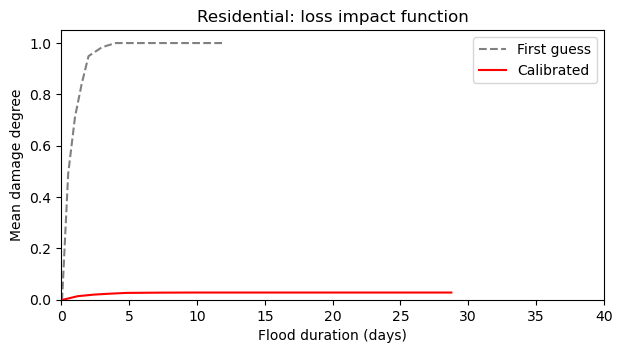

Companies: unfiltered best cost 1.34% (max_damage=0.310, max_intensity=79.75)


2026-08-14 23:10:54,702 - climada.entity.exposures.base - INFO - Exposures matching centroids already found for FL


2026-08-14 23:10:54,704 - climada.engine.impact_calc - INFO - Calculating impact for 21830 assets (>0) and 1 events.


Companies: chosen max_damage=0.30, max_intensity=0.25 -> modelled 442,034,021 USD vs observed 438,755,400 USD (cost 0.75%)


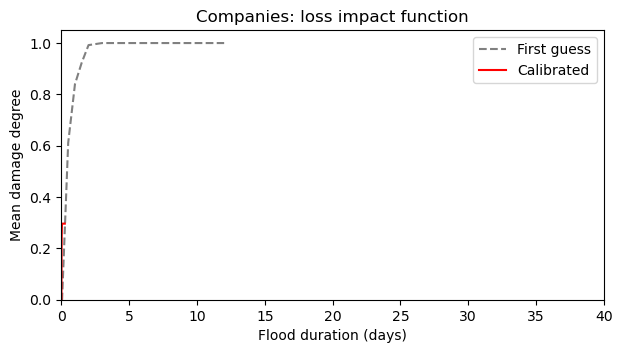

In [8]:
import matplotlib.pyplot as plt

chosen_impfs = {}
for asset, cfg in ASSET_CONFIGS.items():
    results_df = loss_results[asset]["results"]
    impf_orig = loss_results[asset]["impf_orig"]

    best_unfiltered = get_best_result(results_df)
    filtered = results_df[results_df["max_intensity"] < 30]
    best = get_best_result(filtered)
    print(
        f"{asset}: unfiltered best cost {best_unfiltered['cost']:.2f}% "
        f"(max_damage={best_unfiltered['max_damage']:.3f}, "
        f"max_intensity={best_unfiltered['max_intensity']:.2f})"
    )

    # Fine 1-D refinement of max_damage around the coarse-grid best (modelled loss
    # is monotonic in max_damage, so a fine sweep at fixed max_intensity nails it)
    quiet_logs(True)
    fine_values = np.linspace(best["max_damage"] * 0.4, best["max_damage"] * 2.0, 41)
    fine_rows = []
    for max_damage in fine_values:
        impf_new = scale_impf(impf_orig, max_damage, best["max_intensity"])
        entity_new = replace_impact_function(entities[asset]["usd"], impf_new)
        _, modelled = risk_calc(entity_new, haz)
        fine_rows.append({
            "max_damage": max_damage,
            "max_intensity": best["max_intensity"],
            "cost": cost_function(modelled, targets[asset]["loss_usd"]),
        })
    quiet_logs(False)
    best = get_best_result(pd.DataFrame(fine_rows))

    impf_chosen = scale_impf(impf_orig, best["max_damage"], best["max_intensity"])
    impf_chosen.id = cfg["impf_id_loss"]
    impf_chosen.name = impf_orig.name
    chosen_impfs[asset] = impf_chosen

    entity_check = replace_impact_function(entities[asset]["usd"], impf_chosen)
    _, modelled = risk_calc(entity_check, haz)
    cost = cost_function(modelled, targets[asset]["loss_usd"])
    print(
        f"{asset}: chosen max_damage={best['max_damage']:.2f}, "
        f"max_intensity={best['max_intensity']:.2f} -> modelled "
        f"{modelled:,.0f} USD vs observed {targets[asset]['loss_usd']:,.0f} USD "
        f"(cost {cost:.2f}%)"
    )

    fig, axis = plt.subplots(figsize=(7, 3.5))
    axis.plot(impf_orig.intensity, impf_orig.mdd, color="grey", linestyle="--", label="First guess")
    axis.plot(impf_chosen.intensity, impf_chosen.mdd, color="red", label="Calibrated")
    axis.set_xlabel("Flood duration (days)")
    axis.set_ylabel("Mean damage degree")
    axis.set_xlim((0, 40))
    axis.set_ylim((0, 1.05))
    axis.legend()
    axis.set_title(f"{asset}: loss impact function")
    plt.show()
    plt.close(fig)

## Write the calibrated Entity files

Unlike 06a (which prints a table to copy into Excel by hand), we write the calibrated files directly: copy the uncalibrated workbook, replace the `impact_functions` sheet rows with the calibrated loss curve and affected step function, and verify by re-reading with CLIMADA and re-running the risk calculation.

In [9]:
import shutil
import openpyxl

Path(CALIBRATED_ENTITY_DIR).mkdir(exist_ok=True)

for asset, cfg in ASSET_CONFIGS.items():
    src = Path(ENTITY_DIR) / cfg["entity_file"]
    dst = Path(CALIBRATED_ENTITY_DIR) / cfg["calibrated_file"]
    shutil.copyfile(src, dst)

    impf_loss = chosen_impfs[asset]
    impf_affected = step_function(
        affected_results[asset]["best"]["step"],
        fun_id=cfg["impf_id_affected"],
        name=entities[asset]["count"].impact_funcs.get_func(
            haz_type="FL", fun_id=cfg["impf_id_affected"]
        ).name,
    )

    wb = openpyxl.load_workbook(dst)
    ws = wb["impact_functions"]
    header = [c.value for c in ws[1]]
    assert header[:7] == [
        "impact_fun_id", "intensity", "mdd", "paa", "peril_id", "name", "intensity_unit"
    ], f"Unexpected impact_functions header: {header}"

    ws.delete_rows(2, ws.max_row)
    for impf in (impf_loss, impf_affected):
        for inten, mdd, paa in zip(impf.intensity, impf.mdd, impf.paa):
            ws.append([impf.id, float(inten), float(mdd), float(paa), "FL", impf.name, "days"])
    wb.save(dst)

    # Verify: re-read with CLIMADA and reproduce the calibrated numbers
    entity_verify = read_entity(dst, value_column="value")
    entity_verify.exposures.ref_year = 2025
    entity_verify.exposures.value_unit = "USD"
    _, modelled_verify = risk_calc(entity_verify, haz)
    cost_verify = cost_function(modelled_verify, targets[asset]["loss_usd"])
    assert cost_verify < 20, (
        f"{asset}: calibrated file reproduces {modelled_verify:,.0f} USD, "
        f"{cost_verify:.1f}% from observations — check the export"
    )
    print(f"{asset}: wrote {dst.name}; re-read losses {modelled_verify:,.0f} USD ({cost_verify:.2f}% from obs)")

2026-08-14 23:10:57,256 - climada.entity.exposures.base - INFO - Matching 20187 exposures with 1354664 centroids.


2026-08-14 23:10:58,168 - climada.engine.impact_calc - INFO - Calculating impact for 100935 assets (>0) and 1 events.


Residential: wrote Porto_Alegre_BRAZIL_Entity_Floods_Residential_calibrated.xlsx; re-read losses 212,265,415 USD (0.04% from obs)


2026-08-14 23:10:58,983 - climada.entity.exposures.base - INFO - Matching 4366 exposures with 1354664 centroids.


2026-08-14 23:10:59,795 - climada.engine.impact_calc - INFO - Calculating impact for 21830 assets (>0) and 1 events.


Companies: wrote Porto_Alegre_BRAZIL_Entity_Floods_Companies_calibrated.xlsx; re-read losses 442,034,021 USD (0.75% from obs)


## Conclusions

- The *affected* step functions cannot reconcile the model's flooded-point counts with the reported totals, in either direction: Companies can model at most ~4.0k affected businesses (the exposure dataset holds only 4,366 points) against 65.5k reported, while Residential models ~78k flooded units at the best threshold against 39.4k reported *buildings* — the observations' definition of 'affected' and their counting unit don't match the exposure data. As 06a concludes for schools, resolving this needs aligned definitions or a complete asset registry, not further calibration.
- The *loss* calibrations fit a family of near-equivalent curves; the choice inside that family (saturation < 30 days; effective damage cap free, and necessarily far below the schools' 70% because these exposure sets are much broader than the loss totals) is expert judgement and should be revisited with local input. Note the Companies fit saturates at the grid's lowest max_intensity (0.25 days, i.e. effectively a step): with a single loss observation the duration-dependence is unidentifiable, and 'every flooded business loses ~30%' fits as well as any curve.
- The calibrated Entity files are written to `data/entity_files_calibrated/` and verified by re-reading them with CLIMADA and reproducing the calibrated losses (Residential 0.04%, Companies 0.75% from observations).